# Results

This notebook computes and reports every figure quoted in the README, in one place, from the pipeline itself - not transcribed by hand. Run top to bottom to reproduce every number and every chart. See [`02_method.ipynb`](02_method.ipynb) for how the counterfactual is built and validated, and [`DATA.md`](../DATA.md) for full provenance.

**What this notebook is not.** It is not a claim about house prices, and not a claim about London's net fiscal position. Read "What this does not show", at the end, before citing anything from here.

In [1]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd

from council_tax_freeze.config import DATA_DIR, HEADLINE_FIRST_YEAR, LAST_YEAR
from council_tax_freeze.engine.build import build_engine
from council_tax_freeze.hpi.build import build_hpi
from council_tax_freeze.parsers.band_d.parse import build_band_d
from council_tax_freeze.parsers.ctsop.parse import build_ctsop
from council_tax_freeze.parsers.settlement.parse import build_settlement
from council_tax_freeze.aggregates import (
    SINGLE_POT_FLAGGED_LAS,
    compute_la_cumulative_gap,
    compute_london_robustness_check,
    compute_region_cumulative_gap,
)
from council_tax_freeze.boundaries.regions import REGION
from council_tax_freeze.engine.build import compute_shared_tier_exposure, compute_single_pot_bias_risk
from council_tax_freeze.regression.variant3 import build_variant3_panel, run_variant3_regression, within_la_correlation, interpret_offset
from council_tax_freeze.viz.choropleth import plot_gap_choropleth, plot_top_la_bars

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

BAND_D_FILE = DATA_DIR / "band_d" / "Band_D_1993_onwards.ods"
CTSOP_CONSOLIDATED = DATA_DIR / "ctsop" / "CTSOP1_0_1993_2024" / "CTSOP1_0_1993_2024_03_31.csv"
CTSOP_2025 = DATA_DIR / "ctsop" / "2025_summary.xlsx"
SETTLEMENT_FILE = DATA_DIR / "settlement" / "CSP_information_table_LGFS_2025-26.xlsx"
HPI_FILE = sorted((DATA_DIR / "hpi").glob("UK-HPI-full-file-*.csv"))[-1]
BOUNDARY_FILE = DATA_DIR / "boundaries" / "lad_2025.geojson"

bd = build_band_d(BAND_D_FILE)
ct = build_ctsop(CTSOP_CONSOLIDATED, CTSOP_2025)
hpi = build_hpi(HPI_FILE)
eng = build_engine(bd.la_year, ct.la_year, ct.predecessor_weights, hpi.la_factors, hpi.national_factors)

print(f"Headline period: {HEADLINE_FIRST_YEAR} to {LAST_YEAR}")
print(f"296 LAs x {eng.la_year['financial_year'].nunique()} years, {len(eng.la_year):,} LA-year rows, {len(eng.unresolved)} unresolved")

Headline period: 2009-10 to 2025-26
296 LAs x 17 years, 5,032 LA-year rows, 0 unresolved


## The headline

**Per dwelling, per year, is the primary unit throughout this notebook.** It's the figure a reader can check against their own bill, and it's the one that carries every caveat below cleanly - an aggregate figure (below) inherits all of the same caveats plus a few of its own.

The North East is the headline region: low historical appreciation relative to the rest of England, and - checked directly in Phase 4 - the least exposed to this pipeline's one significant known bias (single-pot reallocation, which inflates a handful of inner-London figures, not Northern ones).

In [2]:
la_cum = compute_la_cumulative_gap(eng.la_year, ct.la_year, "variant1")
region_cum = compute_region_cumulative_gap(la_cum).sort_values("per_dwelling_per_year_gbp", ascending=False)

north_east = region_cum.set_index("region").loc["North East"]
hartlepool = la_cum.set_index("ons_code").loc["E06000001"]
hartlepool_2025_dwellings = ct.la_year[(ct.la_year.ons_code == "E06000001") & (ct.la_year.financial_year == "2025-26")]["all_properties"].iloc[0]
hartlepool_per_current_dwelling = hartlepool["cumulative_gap_gbp"] / hartlepool_2025_dwellings

ne_2025_dwellings = ct.la_year[(ct.la_year.financial_year == "2025-26")].merge(
    la_cum[["ons_code", "region"]], on="ons_code"
).query("region == 'North East'")["all_properties"].sum()
ne_cumulative_per_current_dwelling = north_east["cumulative_gap_gbp"] / ne_2025_dwellings
ne_cumulative_per_dwelling_naive_17y = north_east["per_dwelling_per_year_gbp"] * 17

print("North East (region average, dwelling-year-weighted across 12 LAs):")
print(f"  £{north_east['per_dwelling_per_year_gbp']:.2f} / dwelling / year")
print("  Central estimate; empirically-anchored range ~£206-232 (Phase 5 sensitivity sweep - NOT a floor, see below)")
print(f"  ≈ £{ne_cumulative_per_current_dwelling:,.0f} cumulative per CURRENT North East dwelling (region total ÷ 2025-26 dwelling stock)")
print(f"  ≈ £{ne_cumulative_per_dwelling_naive_17y:,.0f} at the region-average rate × 17 years (illustrative only, not the region's real total ÷ dwellings)")
print()
print(f"Hartlepool specifically ({hartlepool['authority']}) — the HIGHEST per-dwelling rate of the region's 12 LAs, but only 3.6% of its dwelling stock:")
print(f"  £{hartlepool['per_dwelling_per_year_gbp']:.2f} / dwelling / year")
print(f"  £{hartlepool['cumulative_gap_gbp']:,.0f} cumulative total, 2009-10 to 2025-26")
print(f"  ≈ £{hartlepool_per_current_dwelling:,.0f} per dwelling currently in Hartlepool, cumulatively, since 2009")
print()
print("These are two different, both real, numbers - a region average and one LA's own figure - not the same quantity rounded differently.")


North East (region average, dwelling-year-weighted across 12 LAs):
  £227.63 / dwelling / year
  Central estimate; empirically-anchored range ~£206-232 (Phase 5 sensitivity sweep - NOT a floor, see below)
  ≈ £3,677 cumulative per CURRENT North East dwelling (region total ÷ 2025-26 dwelling stock)
  ≈ £3,870 at the region-average rate × 17 years (illustrative only, not the region's real total ÷ dwellings)

Hartlepool specifically (Hartlepool UA) — the HIGHEST per-dwelling rate of the region's 12 LAs, but only 3.6% of its dwelling stock:
  £365.52 / dwelling / year
  £270,532,314 cumulative total, 2009-10 to 2025-26
  ≈ £5,863 per dwelling currently in Hartlepool, cumulatively, since 2009

These are two different, both real, numbers - a region average and one LA's own figure - not the same quantity rounded differently.


**Two headline numbers, not one, and they answer different questions.** The North East, on average, has overpaid a central estimate of £227.63 per dwelling per year — roughly £3,700-3,900 cumulatively per dwelling since 2009-10, region-wide. **Hartlepool specifically has overpaid roughly £5,900 per dwelling cumulatively** — its own rate (£365.52/dwelling/year) is the highest of the region's 12 LAs, even though it carries only 3.6% of the region's dwelling stock; the region average is pulled down by larger, lower-rate LAs (Newcastle £162/year, Sunderland £55/year). Neither number is wrong; they are not interchangeable, and a summary that quotes one while implying the other is the same claim would be a real error, not a rounding difference.

London is the arithmetic mirror image of the same closed, revenue-neutral system, not a separate finding about London — see "What this does not show" for why that counterparty is not evidence of anything about London specifically.

In [3]:
region_cum[["region", "per_dwelling_per_year_gbp", "cumulative_gap_gbp_bn"]].rename(columns={
    "per_dwelling_per_year_gbp": "£/dwelling/year",
    "cumulative_gap_gbp_bn": "cumulative £bn",
})

,region,£/dwelling/year,cumulative £bn
3,North East,227.63,4.74
4,North West,124.25,6.91
0,East Midlands,100.88,3.56
8,Yorkshire and The Humber,94.51,3.87
6,South West,55.35,2.37
7,West Midlands,53.14,2.24
5,South East,11.92,0.79
1,East of England,-10.81,-0.49
2,London,-394.92,-23.98


## The map

Diverging red/blue, LA boundaries drawn - the same visual grammar as the Tax Policy Associates LVT model this project was prompted by. Two things are deliberately NOT left to a caption to explain:

- **The colour scale is clipped** to the 2nd/98th percentile of the (unflagged) data, not the raw min/max - a handful of extreme values would otherwise saturate the scale and make every other LA look pale by comparison.
- **The five single-pot-flagged LAs are outlined and hatched**, with their own zoomed inset (they are geographically tiny on an England-wide map, whatever colour they're given) - their figures are upper bounds, not point estimates, and that has to survive a reader who only looks at the picture.

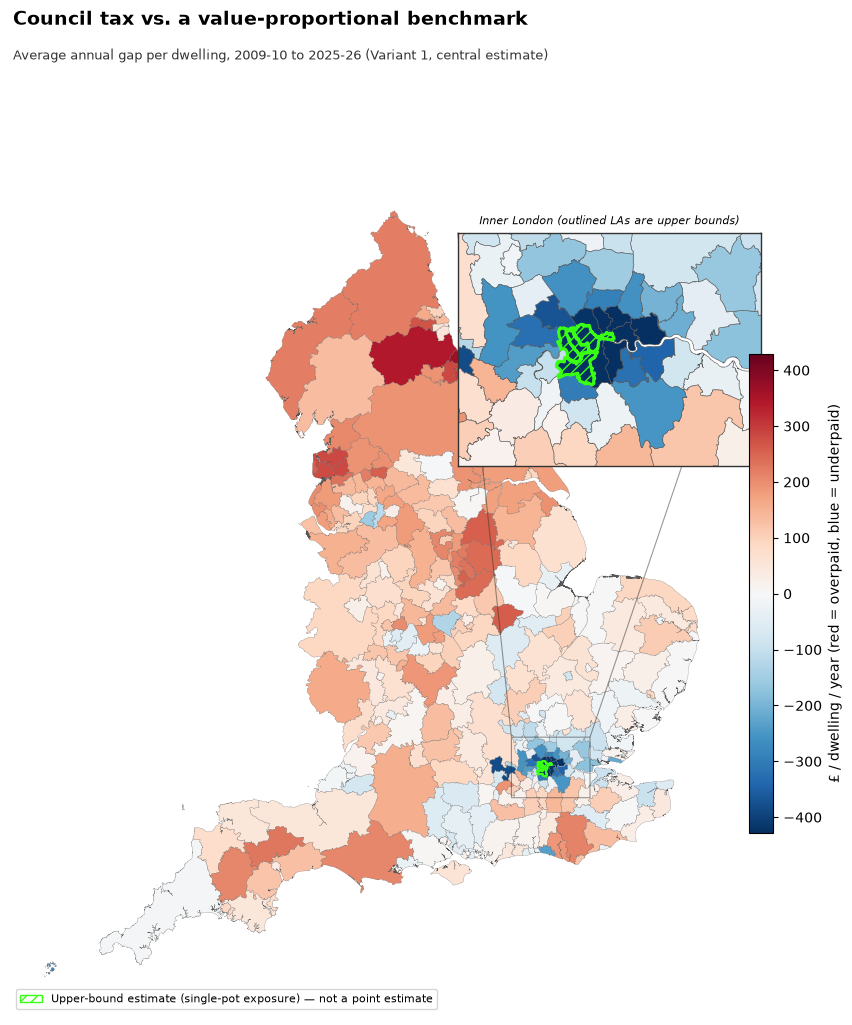

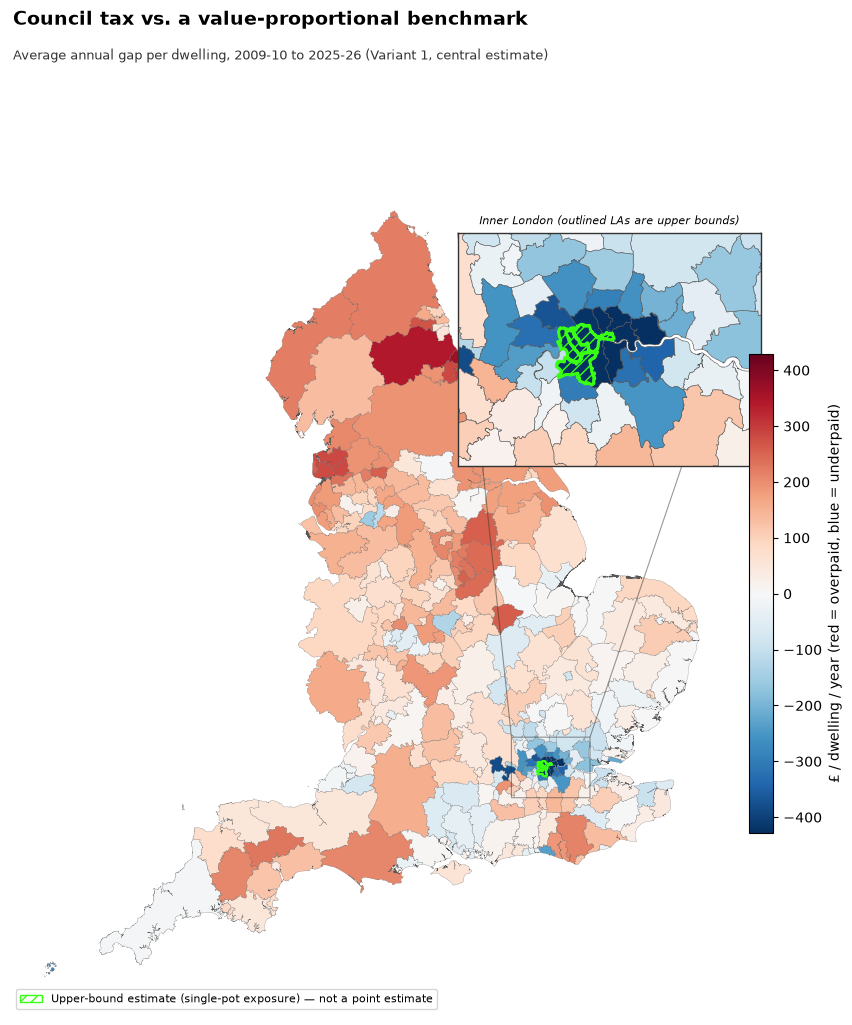

In [4]:
gdf = gpd.read_file(BOUNDARY_FILE)
gdf = gdf[gdf["LAD25CD"].str.startswith("E")]

london_geom = gdf[gdf["LAD25CD"].isin([c for c, r in REGION.items() if r == "London"])]
minx, miny, maxx, maxy = london_geom.total_bounds
pad_x, pad_y = (maxx - minx) * 0.08, (maxy - miny) * 0.08
london_bbox = (minx - pad_x, miny - pad_y, maxx + pad_x, maxy + pad_y)

fig, ax = plot_gap_choropleth(
    gdf, la_cum, value_col="per_dwelling_per_year_gbp",
    flagged_codes=SINGLE_POT_FLAGGED_LAS,
    title="Council tax vs. a value-proportional benchmark",
    subtitle="Average annual gap per dwelling, 2009-10 to 2025-26 (Variant 1, central estimate)",
    legend_label="£ / dwelling / year (red = overpaid, blue = underpaid)",
    inset_bbox=london_bbox,
    inset_label="Inner London (outlined LAs are upper bounds)",
)
fig.savefig("../outputs/choropleth_variant1.png", dpi=150, bbox_inches="tight")
fig


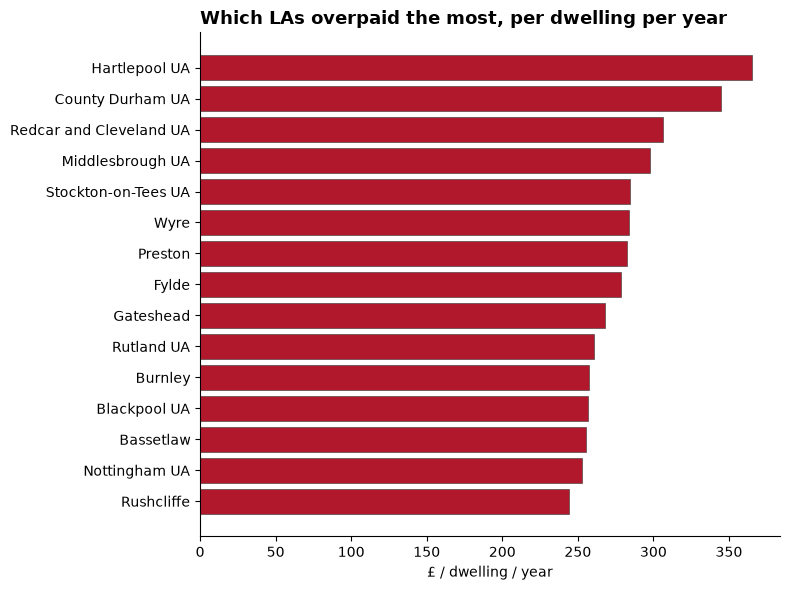

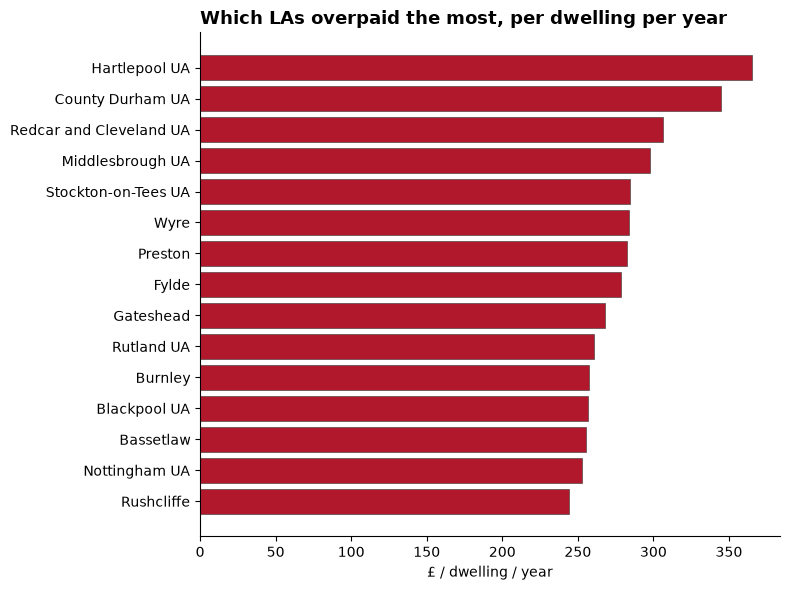

In [5]:
fig, ax = plot_top_la_bars(
    la_cum, value_col="per_dwelling_per_year_gbp", name_col="authority", n=15, direction="positive",
    title="Which LAs overpaid the most, per dwelling per year",
    xlabel="£ / dwelling / year",
)
fig.savefig("../outputs/bars_overpaid.png", dpi=130, bbox_inches="tight")
fig


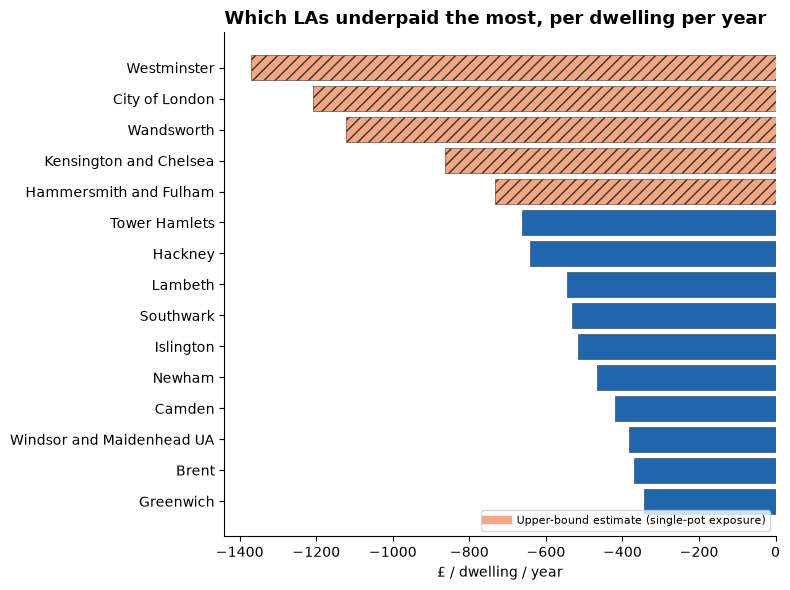

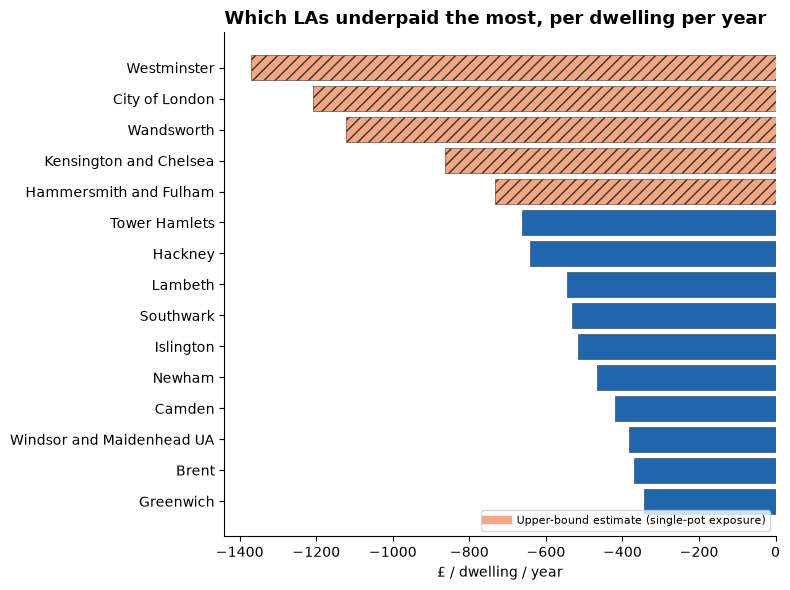

In [6]:
fig, ax = plot_top_la_bars(
    la_cum, value_col="per_dwelling_per_year_gbp", name_col="authority", n=15, direction="negative",
    flagged_codes=SINGLE_POT_FLAGGED_LAS,
    title="Which LAs underpaid the most, per dwelling per year",
    xlabel="£ / dwelling / year", color="#2166ac",
)
fig.savefig("../outputs/bars_underpaid.png", dpi=130, bbox_inches="tight")
fig


Ten of the fifteen LAs on the "underpaid the most" chart are NOT single-pot-flagged (Tower Hamlets, Hackney, Lambeth, Southwark, Islington, Newham, Camden, Windsor and Maidenhead, Brent, Greenwich) - inner London's underpayment is real and not solely an artefact of the five outlier LAs, even though those five specifically need the upper-bound caveat.

## Aggregates: a second unit of analysis, and a missing ledger entry

The per-dwelling figure above is the honest primary unit and stays primary. But the debate this analysis lands in - "London funds the rest of the country" - is conducted in £-billions of regional net fiscal transfer, and a £-per-household figure cannot answer a £-billions claim on its own. They are different currencies. This section reports both.

**Computed correctly, not by a shortcut that would not survive scrutiny.** The aggregate figures below are built by summing each LA's own already-correct ANNUAL gap (in £, not £/dwelling) across the 17 headline years - each year already reflects that year's real Band D rates and real dwelling stock. They are NOT the panel-average per-dwelling figure multiplied by a current dwelling count: dwelling stock grew materially over 2009-2026, and that shortcut would overstate the true cumulative total by assuming today's housing stock existed throughout the period. `tests/test_aggregates.py` pins the two methods disagreeing, specifically so this cannot later be "simplified" back.

**What the claim is, and what it is not.** The regional net-transfer figures everyone cites do not include this. Council tax's frozen 1991 valuation base has transferred several billion pounds from low-appreciation to high-appreciation regions over seventeen years, through the tax system itself, in the opposite direction to the standard "London subsidises the regions" narrative - and it has never been counted. **That is the claim. This notebook does not make, and the numbers below do not support, any claim about London's overall net fiscal position** - council tax is one tax among many, and net fiscal balance also depends on income tax, VAT, corporation tax, and public spending allocation, none of which this pipeline touches.

In [7]:
region_cum_sorted = region_cum.sort_values("cumulative_gap_gbp")
region_cum_sorted[["region", "cumulative_gap_gbp_bn", "per_dwelling_per_year_gbp"]].rename(columns={
    "cumulative_gap_gbp_bn": "cumulative £bn, 2009-26",
    "per_dwelling_per_year_gbp": "£/dwelling/year",
})

,region,"cumulative £bn, 2009-26",£/dwelling/year
2,London,-23.98,-394.92
1,East of England,-0.49,-10.81
5,South East,0.79,11.92
7,West Midlands,2.24,53.14
6,South West,2.37,55.35
0,East Midlands,3.56,100.88
8,Yorkshire and The Humber,3.87,94.51
3,North East,4.74,227.63
4,North West,6.91,124.25


### The asymmetry that must stay visible in aggregate form

Publishing "the North East overpaid £4.7bn" makes the counterparty - "London underpaid £24.0bn" - immediately visible and quotable. But London's figures are the ones already downgraded to upper bounds because of single-pot exposure (Phase 4), and Westminster/Wandsworth/Hammersmith and Fulham/City of London/Kensington and Chelsea are the five worst cases. The aggregate must not quietly re-import a caveat already accepted on the other side of the ledger.

In [8]:
london_check = compute_london_robustness_check(la_cum)
print(f"London, robust figure (33 boroughs EXCLUDING the 5 single-pot-exposed): £{london_check['london_total_excl_flagged_gbp_bn']:.2f}bn  <- lead with this one")
print(f"London, all 33 boroughs (includes the 5 upper-bound estimates):        £{london_check['london_total_gbp_bn']:.2f}bn")
print(f"Share of the all-boroughs total that comes from the 5 flagged LAs: {london_check['flagged_five_share_of_london_total']:.1%}")
print()
north_east_flagged = set(la_cum[la_cum['region']=='North East']['ons_code']) & set(SINGLE_POT_FLAGGED_LAS)
print(f"North East LAs among the single-pot-flagged five: {len(north_east_flagged)} (of {len(SINGLE_POT_FLAGGED_LAS)} total) - no equivalent caveat on the North East figure")


London, robust figure (33 boroughs EXCLUDING the 5 single-pot-exposed): £-15.79bn  <- lead with this one
London, all 33 boroughs (includes the 5 upper-bound estimates):        £-23.98bn
Share of the all-boroughs total that comes from the 5 flagged LAs: 34.2%

North East LAs among the single-pot-flagged five: 0 (of 5 total) - no equivalent caveat on the North East figure


**London's aggregate is −£24.0bn across all 33 boroughs, of which −£15.8bn excludes the five single-pot-exposed boroughs — the second figure, not the first, is the one to lead with.** Roughly a third (34.2%) of the headline −£24.0bn sits in cells this notebook has already told readers are inflated upper bounds; a reader should not have to do that subtraction themselves to find the load-bearing number, so it is done here. The remaining −£15.8bn, from the other 28 boroughs, is not subject to that caveat and is comparably robust to the North East figure.

**The North East aggregate carries no equivalent caveat.** None of the five single-pot-flagged LAs are in the North East; shared-tier exposure there is 14-16% (Phase 4), an order of magnitude below the 41% exposure that makes Westminster's figure unreliable; and Variant 3 (below) found no rate-setting compensation effect for non-London LAs to worry about either. That asymmetry is a strength of this analysis, not an inconvenience: the side of the ledger the headline leads with is the side the method handles best.

## Variant 2: a separate, secondary finding

Variant 1 (above) isolates the effect of the frozen valuation date alone - the headline. Variant 2 adds full proportionality (removing the compressed 6/9-18/9 multiplier structure too) and is reported separately because it measures a different mechanism: the compression effect concentrates in Elmbridge, Guildford, Mole Valley and Sevenoaks - Surrey commuter towns with 3-4x the national share of dwellings in Bands F-H - not in the North/South divide. See [`02_method.ipynb`](02_method.ipynb) "Variant 1 is the headline" for the full derivation (including why the two variants disagreeing in sign for 20% of LAs is a finding, not a bug: r = -0.69 with an LA's Band F-H share).

## Variant 3: did rate-setting already fix this?

Tested directly - the strongest form of the IFS (2020) objection - and it does not hold outside London. Full derivation, the robustness checks, and the diagnosis (confounding via the same business-rate/reserves mechanism Phase 4 found for Westminster/Wandsworth, not genuine compensation) are in [`02_method.ipynb`](02_method.ipynb) "Variant 3". Headline numbers, reproduced here:

In [9]:
settlement = build_settlement(SETTLEMENT_FILE, ct.la_year)
v3_panel = build_variant3_panel(bd.la_year, ct.la_year, hpi.la_factors, hpi.national_factors, settlement.la_year)

pooled = run_variant3_regression(v3_panel, "pooled")
non_london = run_variant3_regression(v3_panel, "non_london")

print(f"Pooled (296 LAs):     coef={pooled.coefficient:.4f}  CI=[{pooled.conf_int[0]:.4f}, {pooled.conf_int[1]:.4f}]  p={pooled.pvalue:.4f}")
print(f"Non-London (263 LAs): coef={non_london.coefficient:.4f}  CI=[{non_london.conf_int[0]:.4f}, {non_london.conf_int[1]:.4f}]  p={non_london.pvalue:.4f}  <- primary result, a tight null")
print()
print(f"Within-LA correlation, London:     {within_la_correlation(v3_panel, 'london'):.2f}")
print(f"Within-LA correlation, non-London: {within_la_correlation(v3_panel, 'non_london'):.2f}")
print()
for code_, name in [("E06000001", "Hartlepool"), ("E06000047", "County Durham"), ("E06000009", "Blackpool")]:
    interp = interpret_offset(non_london, eng.la_year, code_, bound="ceiling")
    print(f"{name}: at most {interp['implied_offset_share_of_measured_gap']:.1%} of its measured gap, even at the ceiling of the non-London CI")

Pooled (296 LAs):     coef=-0.0243  CI=[-0.0318, -0.0167]  p=0.0000
Non-London (263 LAs): coef=-0.0063  CI=[-0.0143, 0.0017]  p=0.1252  <- primary result, a tight null

Within-LA correlation, London:     -0.57
Within-LA correlation, non-London: 0.08

Hartlepool: at most 1.7% of its measured gap, even at the ceiling of the non-London CI
County Durham: at most 1.7% of its measured gap, even at the ceiling of the non-London CI
Blackpool: at most 2.3% of its measured gap, even at the ceiling of the non-London CI


## What this does not show

- **Not a causal claim about house prices.** This pipeline estimates a redistributive gap in the tax system, not the effect of council tax on property prices. Capitalisation of low relative tax burden into higher prices is theoretically plausible, but has not been estimated here, and none of the figures above should be read as implying it.
- **Not a novel mechanism.** IFS (2020) established the direction of this effect and its cause (the frozen 1991 valuation base combined with a funding settlement that still references it) years before this analysis existed - see [`02_method.ipynb`](02_method.ipynb) "This is not a novel mechanism". What this pipeline adds is the accumulated MAGNITUDE over seventeen years at LA level, which IFS's snapshot methodology does not publish - the stock, not the flow they already described.
- **The floor framing is gone, and it must not quietly come back.** £227.63/dwelling/year (North East) is a central estimate within an empirically-anchored range of roughly £206-232, not a demonstrated lower bound - Phase 5's sensitivity sweep found the base-case midpoint assumptions do not sit at the conservative edge of the plausible range the way earlier phases believed. "At least £227.63" is a more attractive sentence than "a central estimate of £227.63, plausibly £206-232" and it will keep wanting to creep back into future summaries of this work. It should not.
- **Variant 3's non-London result is a tight null, not proof of no relationship.** The 95% CI, [-0.0143, +0.0017], rules out an economically meaningful rate-setting response to appreciation across 263 non-London LAs over eleven years - it does not prove the true coefficient is exactly zero, only that the data are precise enough to rule out anything large.
- **Every figure for Westminster, Wandsworth, Hammersmith and Fulham, City of London and Kensington and Chelsea is an upper bound**, inflated by the single-pot reallocation method (Phase 4) - not a point estimate, and not comparable on equal footing to any other LA's figure in this notebook, including in the aggregate section above.
- **Not a claim about London's net fiscal position.** The aggregate figures above are a missing entry in the regional-transfer ledger, not a competing one - see "Aggregates", above. This pipeline does not model income tax, VAT, corporation tax, or public spending, and says nothing about whether London is a net contributor to or recipient from the rest of the country once those are accounted for.
- **The mechanism is an accounting identity, not a conspiracy.** A revenue-neutral reallocation is a closed system: the North's measured overpayment and the South's measured underpayment are two views of the same frozen 1991 valuation base, not two independent findings that happen to point the same way. Nobody chose this outcome in any given year; it is the mechanical consequence of never revaluing since 1991 while property values diverged. Read that way, this is a finding about a tax that needs updating, not a finding about who is or isn't paying their fair share today.

## Reproducing this notebook

```
make data   # fetches everything download.py can fetch automatically; prints instructions for the rest
jupyter nbconvert --to notebook --execute notebooks/03_results.ipynb
```

Every number above is computed live from the files in `data/` (gitignored - see `DATA.md`) via the pipeline in `src/council_tax_freeze/`, not transcribed.